In [1]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline


#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.tools.layout_functions import visualize_layout
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

In [2]:
df_wind_montly = pd.read_csv('../2020_Daily_Avgs.csv')
df_wind_montly.head()

list_wd_bins = [0., 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80., 85., 90., 95., 100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260., 265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315., 320., 325., 330., 335., 340., 345., 350., 355.]

list_ws_bins = [0., 1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.]

windr = WindRose()

df_wind_calc = windr.make_wind_rose_from_user_data(wd_raw=df_wind_montly['average_wind_dir_deg'], ws_raw=df_wind_montly['Factorized_Mean'], wd=np.array(list_wd_bins), ws=np.array(list_ws_bins))


wd_array = np.array(df_wind_calc["wd"].unique(), dtype=float)
ws_array = np.array(df_wind_calc["ws"].unique(), dtype=float)


wd_grid, ws_grid = np.meshgrid(wd_array, ws_array, indexing="ij")
freq_interp = NearestNDInterpolator(df_wind_calc[["wd", "ws"]], df_wind_calc["freq_val"])
freq = freq_interp(wd_grid, ws_grid)

# Normalize the frequency array to sum to exactly 1.0
freq = freq / np.sum(freq)

Correcting negative Overhang:-2.5


In [3]:
df_vestas = pd.read_csv('../pop_fav.csv')
df_nrel = pd.read_csv('../gen_2_13.csv')

In [4]:
fi_powers_vestas = FlorisInterface('./vestas_jensen.yaml')

In [5]:
def aep_powers(fi, wind_shear):
    power_list = []
    fi.reinitialize(
        wind_directions=wd_array,
        wind_speeds=ws_array,
        wind_shear=wind_shear,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list

In [20]:
fi_powers_nrel = FlorisInterface('./nrel_jensen.yaml')

In [10]:
power_loss_90_110 = []
p_with_w_90_110 = []
p_without_w_90_110 = []

In [11]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_nrel, i)
    power_loss_90_110.append(power_p[2])
    p_with_w_90_110.append(power_p[0])
    p_without_w_90_110.append(power_p[1])

In [13]:
power_loss_90_115 = []
p_with_w_90_115 = []
p_without_w_90_115 = []

In [14]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_nrel, i)
    power_loss_90_115.append(power_p[2])
    p_with_w_90_115.append(power_p[0])
    p_without_w_90_115.append(power_p[1])


In [18]:
power_loss_90_125 = []
p_with_w_90_125 = []
p_without_w_90_125 = [] 

In [19]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_nrel, i)
    power_loss_90_125.append(power_p[2])
    p_with_w_90_125.append(power_p[0])
    p_without_w_90_125.append(power_p[1])

In [23]:
power_loss_90 = []
p_with_w_90 = []
p_without_w_90 = [] 

In [24]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_nrel, i)
    power_loss_90.append(power_p[2])
    p_with_w_90.append(power_p[0])
    p_without_w_90.append(power_p[1])

In [ ]:
fi_powers_vestas = FlorisInterface('./vestas_jensen.yaml')

In [26]:
x_axis = np.arange(0.16, 0.37, 0.02)

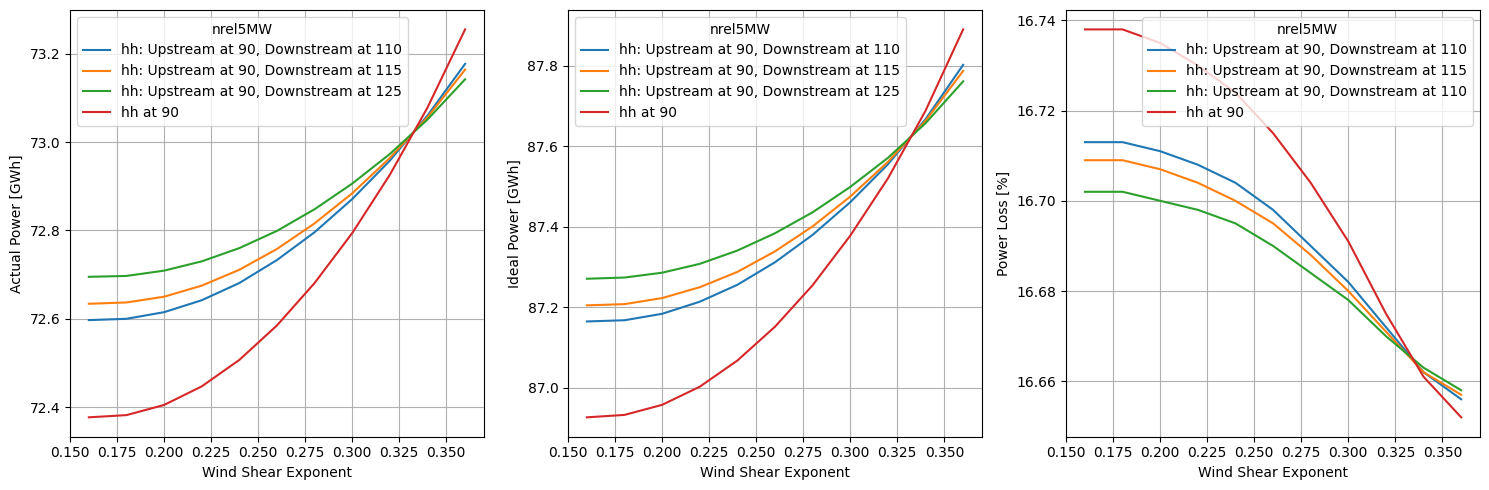

In [29]:
fig, axarr = plt.subplots(1, 3, figsize=(15, 5))

# Plot Actual Power
ax = axarr[0]
ax.plot(x_axis, p_with_w_90_110, label='hh: Upstream at 90, Downstream at 110')
ax.plot(x_axis, p_with_w_90_115, label='hh: Upstream at 90, Downstream at 115')
ax.plot(x_axis, p_with_w_90_125, label='hh: Upstream at 90, Downstream at 125')
ax.plot(x_axis, p_with_w_90, label='hh at 90')
ax.set_xlabel('Wind Shear Exponent')
ax.set_ylabel('Actual Power [GWh]')
ax.legend(title="nrel5MW",)
ax.grid()
# Plot Ideal Power
ax = axarr[1]
ax.plot(x_axis, p_without_w_90_110, label='hh: Upstream at 90, Downstream at 110')
ax.plot(x_axis, p_without_w_90_115, label='hh: Upstream at 90, Downstream at 115')
ax.plot(x_axis, p_without_w_90_125, label='hh: Upstream at 90, Downstream at 125')
ax.plot(x_axis, p_without_w_90, label='hh at 90')
ax.set_xlabel('Wind Shear Exponent')
ax.set_ylabel('Ideal Power [GWh]')
ax.legend(title="nrel5MW",)
ax.grid()

# Plot Power Loss
ax = axarr[2]
ax.plot(x_axis, power_loss_90_110, label='hh: Upstream at 90, Downstream at 110')
ax.plot(x_axis, power_loss_90_115, label='hh: Upstream at 90, Downstream at 115')
ax.plot(x_axis, power_loss_90_125, label='hh: Upstream at 90, Downstream at 110')
ax.plot(x_axis, power_loss_90, label='hh at 90')
ax.set_xlabel('Wind Shear Exponent')
ax.set_ylabel('Power Loss [%]')
ax.legend(
    title="nrel5MW",
)
ax.grid()

plt.tight_layout()

plt.show()

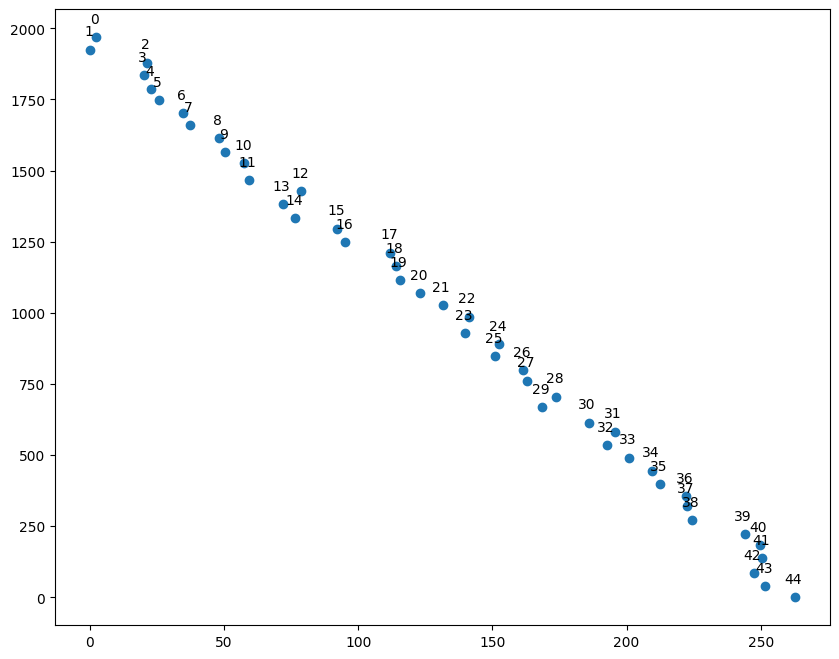

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(df_vestas["Layout_x"], df_vestas["Layout_y"], 'o')
# Label each point with its index
for i, (x, y) in enumerate(zip(df_vestas["Layout_x"], df_vestas["Layout_y"])):
    ax.annotate(i, (x, y), textcoords="offset points", xytext=(-1,10), ha='center')
plt.show()
